# Drug Response Prediction - Model Comparison

This notebook provides a comprehensive comparison of all trained models including:
- LightGBM Baseline
- MLP Baseline (5-fold CV)
- MLP with ChemBERTa embeddings
- MLP + ChemBERTa (Tuned)
- GNN Baseline
- GNN (Tuned)
- ChemBERTa Fine-tuned

We'll compare performance metrics (RMSE, MAE, Spearman correlation) and visualize the results.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

## 2. Load Model Results

Load metrics from all trained models stored in the `results/` directory.

In [2]:
# Define results directory
results_dir = Path("../results")

# Load LightGBM baseline
lgbm_cv = pd.read_csv(results_dir / "baseline_lgbm/cv_metrics.csv")
lgbm_metrics = {
    'model': 'LightGBM Baseline',
    'rmse_val': lgbm_cv['rmse'].mean(),
    'mae_val': lgbm_cv['mae'].mean(),
    'spearman_val': lgbm_cv['spearman'].mean(),
    'rmse_test': np.nan,  # CV only
    'mae_test': np.nan,
    'spearman_test': np.nan
}

# Load MLP Baseline (5-fold CV)
mlp_cv = pd.read_csv(results_dir / "mlp_baseline/cv_metrics.csv")
mlp_baseline_metrics = {
    'model': 'MLP Baseline (CV)',
    'rmse_val': mlp_cv['rmse'].mean(),
    'mae_val': mlp_cv['mae'].mean(),
    'spearman_val': mlp_cv['spearman'].mean(),
    'rmse_test': np.nan,
    'mae_test': np.nan,
    'spearman_test': np.nan
}

# Load MLP with splits
mlp_splits = pd.read_csv(results_dir / "mlp_baseline_with_splits/metrics_val_test.csv")
mlp_splits_metrics = {
    'model': 'MLP Baseline',
    'rmse_val': mlp_splits[mlp_splits['split']=='val']['rmse'].values[0],
    'mae_val': mlp_splits[mlp_splits['split']=='val']['mae'].values[0],
    'spearman_val': mlp_splits[mlp_splits['split']=='val']['spearman'].values[0],
    'rmse_test': mlp_splits[mlp_splits['split']=='test']['rmse'].values[0],
    'mae_test': mlp_splits[mlp_splits['split']=='test']['mae'].values[0],
    'spearman_test': mlp_splits[mlp_splits['split']=='test']['spearman'].values[0]
}

# Load MLP + ChemBERTa
mlp_chemberta = pd.read_csv(results_dir / "mlp_chemberta/metrics_val_test.csv")
mlp_chemberta_metrics = {
    'model': 'MLP + ChemBERTa',
    'rmse_val': mlp_chemberta[mlp_chemberta['split']=='val']['rmse'].values[0],
    'mae_val': mlp_chemberta[mlp_chemberta['split']=='val']['mae'].values[0],
    'spearman_val': mlp_chemberta[mlp_chemberta['split']=='val']['spearman'].values[0],
    'rmse_test': mlp_chemberta[mlp_chemberta['split']=='test']['rmse'].values[0],
    'mae_test': mlp_chemberta[mlp_chemberta['split']=='test']['mae'].values[0],
    'spearman_test': mlp_chemberta[mlp_chemberta['split']=='test']['spearman'].values[0]
}

# Load MLP + ChemBERTa Tuned
mlp_tuned = pd.read_csv(results_dir / "mlp_chemberta_tuned/final_test_metrics.csv")
mlp_tuned_metrics = {
    'model': 'MLP + ChemBERTa (Tuned)',
    'rmse_val': np.nan,
    'mae_val': np.nan,
    'spearman_val': np.nan,
    'rmse_test': mlp_tuned['rmse'].values[0],
    'mae_test': mlp_tuned['mae'].values[0],
    'spearman_test': mlp_tuned['spearman'].values[0]
}

# Load GNN Baseline
gnn_baseline = pd.read_csv(results_dir / "gnn_baseline/metrics_val_test.csv")
gnn_baseline_metrics = {
    'model': 'GNN Baseline',
    'rmse_val': gnn_baseline[gnn_baseline['split']=='val']['rmse'].values[0],
    'mae_val': gnn_baseline[gnn_baseline['split']=='val']['mae'].values[0],
    'spearman_val': gnn_baseline[gnn_baseline['split']=='val']['spearman'].values[0],
    'rmse_test': gnn_baseline[gnn_baseline['split']=='test']['rmse'].values[0],
    'mae_test': gnn_baseline[gnn_baseline['split']=='test']['mae'].values[0],
    'spearman_test': gnn_baseline[gnn_baseline['split']=='test']['spearman'].values[0]
}

# Load GNN Tuned
gnn_tuned = pd.read_csv(results_dir / "gnn_tuned/metrics_val_test.csv")
gnn_tuned_metrics = {
    'model': 'GNN (Tuned)',
    'rmse_val': gnn_tuned[gnn_tuned['split']=='val']['rmse'].values[0],
    'mae_val': gnn_tuned[gnn_tuned['split']=='val']['mae'].values[0],
    'spearman_val': gnn_tuned[gnn_tuned['split']=='val']['spearman'].values[0],
    'rmse_test': gnn_tuned[gnn_tuned['split']=='test']['rmse'].values[0],
    'mae_test': gnn_tuned[gnn_tuned['split']=='test']['mae'].values[0],
    'spearman_test': gnn_tuned[gnn_tuned['split']=='test']['spearman'].values[0]
}

# Load ChemBERTa Fine-tuned
chemberta_ft = pd.read_csv(results_dir / "chemberta_finetune/metrics_val_test.csv")
chemberta_ft_metrics = {
    'model': 'ChemBERTa (Fine-tuned)',
    'rmse_val': chemberta_ft[chemberta_ft['split']=='val']['rmse'].values[0],
    'mae_val': chemberta_ft[chemberta_ft['split']=='val']['mae'].values[0],
    'spearman_val': chemberta_ft[chemberta_ft['split']=='val']['spearman'].values[0],
    'rmse_test': chemberta_ft[chemberta_ft['split']=='test']['rmse'].values[0],
    'mae_test': chemberta_ft[chemberta_ft['split']=='test']['mae'].values[0],
    'spearman_test': chemberta_ft[chemberta_ft['split']=='test']['spearman'].values[0]
}

print("✓ All model results loaded successfully!")

✓ All model results loaded successfully!


## 3. Create Comprehensive Comparison Table

Combine all metrics into a single DataFrame for easy comparison.

In [3]:
# Combine all metrics into a DataFrame
all_metrics = [
    lgbm_metrics,
    mlp_baseline_metrics,
    mlp_splits_metrics,
    mlp_chemberta_metrics,
    mlp_tuned_metrics,
    gnn_baseline_metrics,
    gnn_tuned_metrics,
    chemberta_ft_metrics
]

df_results = pd.DataFrame(all_metrics)

# Round values for better display
df_results = df_results.round(4)

# Display the full comparison table
print("=" * 90)
print("COMPLETE MODEL COMPARISON - ALL METRICS")
print("=" * 90)
display(df_results)

COMPLETE MODEL COMPARISON - ALL METRICS


,model,rmse_val,mae_val,spearman_val,rmse_test,mae_test,spearman_test
0,LightGBM Baseline,2.2491,1.7502,0.4623,NaN,NaN,NaN
1,MLP Baseline (CV),2.3145,1.7854,0.4316,NaN,NaN,NaN
2,MLP Baseline,2.3399,1.8286,0.4821,2.6935,2.1215,0.3559
3,MLP + ChemBERTa,2.1147,1.6371,0.5207,2.5876,1.9922,0.4069
4,MLP + ChemBERTa (Tuned),NaN,NaN,NaN,2.3920,1.9038,0.4498
5,GNN Baseline,2.2200,1.6950,0.5020,2.7090,2.1335,0.3454
6,GNN (Tuned),2.1349,1.6786,0.5226,2.5641,2.0064,0.3328
7,ChemBERTa (Fine-tuned),1.9915,1.5587,0.5549,2.5586,1.9667,0.3622


## 4. Create Styled Comparison Tables

Apply styling to highlight best performances for each metric.

In [4]:
# Create styled version highlighting best values
# Lower is better for RMSE and MAE, higher is better for Spearman

def highlight_best(s, metrics_lower_better=['rmse_val', 'rmse_test', 'mae_val', 'mae_test']):
    """Highlight best value in each column"""
    if s.name == 'model':
        return [''] * len(s)
    
    # Skip if all NaN
    if s.isna().all():
        return [''] * len(s)
    
    if s.name in metrics_lower_better:
        # Lower is better
        is_best = s == s.min()
    else:
        # Higher is better (Spearman)
        is_best = s == s.max()
    
    return ['background-color: lightgreen; font-weight: bold' if v else '' for v in is_best]

styled_df = df_results.style\
    .apply(highlight_best, axis=0)\
    .format(precision=4, na_rep='-')\
    .set_caption("Model Performance Comparison (Best values highlighted in green)")

display(styled_df)

,model,rmse_val,mae_val,spearman_val,rmse_test,mae_test,spearman_test
0,LightGBM Baseline,2.2491,1.7502,0.4623,-,-,-
1,MLP Baseline (CV),2.3145,1.7854,0.4316,-,-,-
2,MLP Baseline,2.3399,1.8286,0.4821,2.6935,2.1215,0.3559
3,MLP + ChemBERTa,2.1147,1.6371,0.5207,2.5876,1.9922,0.4069
4,MLP + ChemBERTa (Tuned),-,-,-,2.3920,1.9038,0.4498
5,GNN Baseline,2.2200,1.6950,0.5020,2.7090,2.1335,0.3454
6,GNN (Tuned),2.1349,1.6786,0.5226,2.5641,2.0064,0.3328
7,ChemBERTa (Fine-tuned),1.9915,1.5587,0.5549,2.5586,1.9667,0.3622


## 5. Test Set Performance Summary

Focus on test set performance for models that have test metrics.

In [5]:
# Filter models with test metrics
df_test = df_results[df_results['rmse_test'].notna()][['model', 'rmse_test', 'mae_test', 'spearman_test']].copy()
df_test.columns = ['Model', 'RMSE', 'MAE', 'Spearman Correlation']

# Sort by Spearman correlation (higher is better)
df_test = df_test.sort_values('Spearman Correlation', ascending=False).reset_index(drop=True)

print("=" * 80)
print("TEST SET PERFORMANCE SUMMARY (Sorted by Spearman Correlation)")
print("=" * 80)
display(df_test)

# Find best model
best_model = df_test.iloc[0]['Model']
best_spearman = df_test.iloc[0]['Spearman Correlation']

print(f"\n🏆 Best Test Performance: {best_model} (Spearman = {best_spearman:.4f})")

TEST SET PERFORMANCE SUMMARY (Sorted by Spearman Correlation)


,Model,RMSE,MAE,Spearman Correlation
0,MLP + ChemBERTa (Tuned),2.3920,1.9038,0.4498
1,MLP + ChemBERTa,2.5876,1.9922,0.4069
2,ChemBERTa (Fine-tuned),2.5586,1.9667,0.3622
3,MLP Baseline,2.6935,2.1215,0.3559
4,GNN Baseline,2.7090,2.1335,0.3454
5,GNN (Tuned),2.5641,2.0064,0.3328



🏆 Best Test Performance: MLP + ChemBERTa (Tuned) (Spearman = 0.4498)


## 6. Visualize Performance Comparison

Create bar charts comparing all models across different metrics.

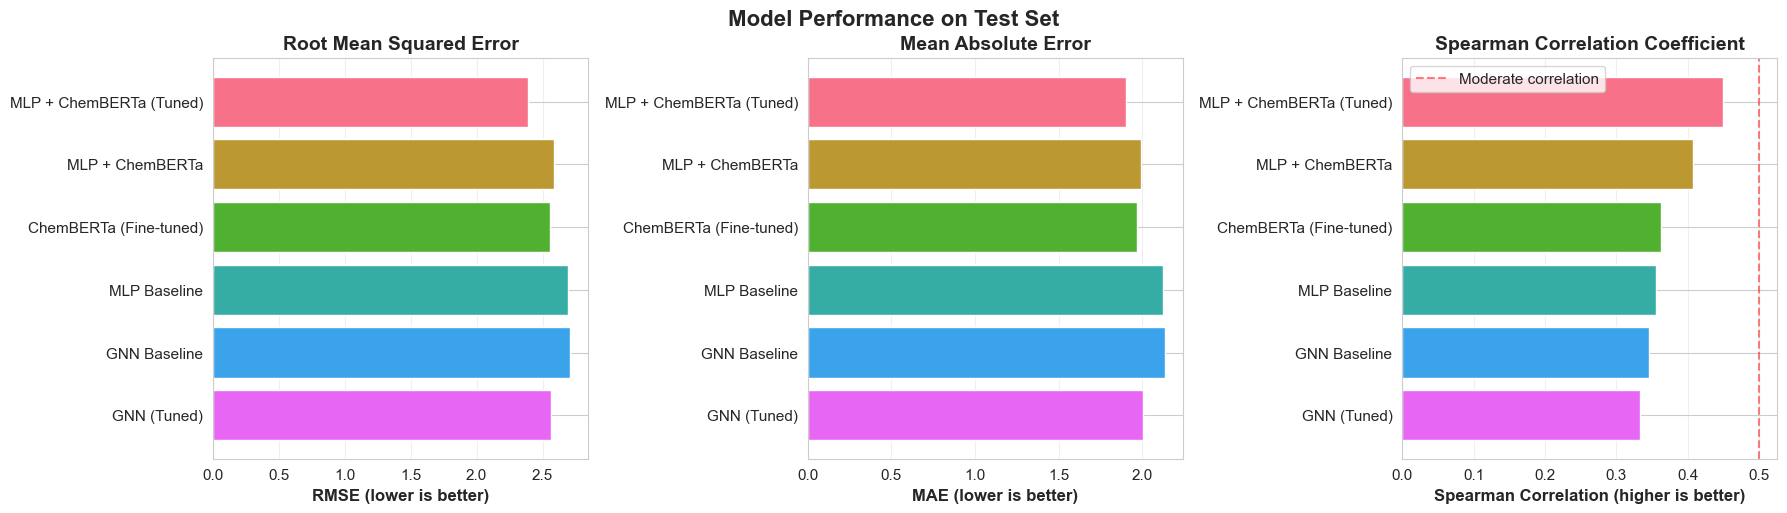

In [6]:
# Prepare data for visualization (test set only)
df_viz = df_test.copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Color palette
colors = sns.color_palette("husl", len(df_viz))

# Plot 1: RMSE
axes[0].barh(df_viz['Model'], df_viz['RMSE'], color=colors)
axes[0].set_xlabel('RMSE (lower is better)', fontsize=12, fontweight='bold')
axes[0].set_title('Root Mean Squared Error', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Plot 2: MAE
axes[1].barh(df_viz['Model'], df_viz['MAE'], color=colors)
axes[1].set_xlabel('MAE (lower is better)', fontsize=12, fontweight='bold')
axes[1].set_title('Mean Absolute Error', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

# Plot 3: Spearman Correlation
axes[2].barh(df_viz['Model'], df_viz['Spearman Correlation'], color=colors)
axes[2].set_xlabel('Spearman Correlation (higher is better)', fontsize=12, fontweight='bold')
axes[2].set_title('Spearman Correlation Coefficient', fontsize=14, fontweight='bold')
axes[2].invert_yaxis()
axes[2].grid(axis='x', alpha=0.3)
axes[2].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Moderate correlation')
axes[2].legend()

plt.tight_layout()
plt.suptitle('Model Performance on Test Set', fontsize=16, fontweight='bold', y=1.02)
plt.show()

## 7. Grouped Bar Chart - All Metrics Together

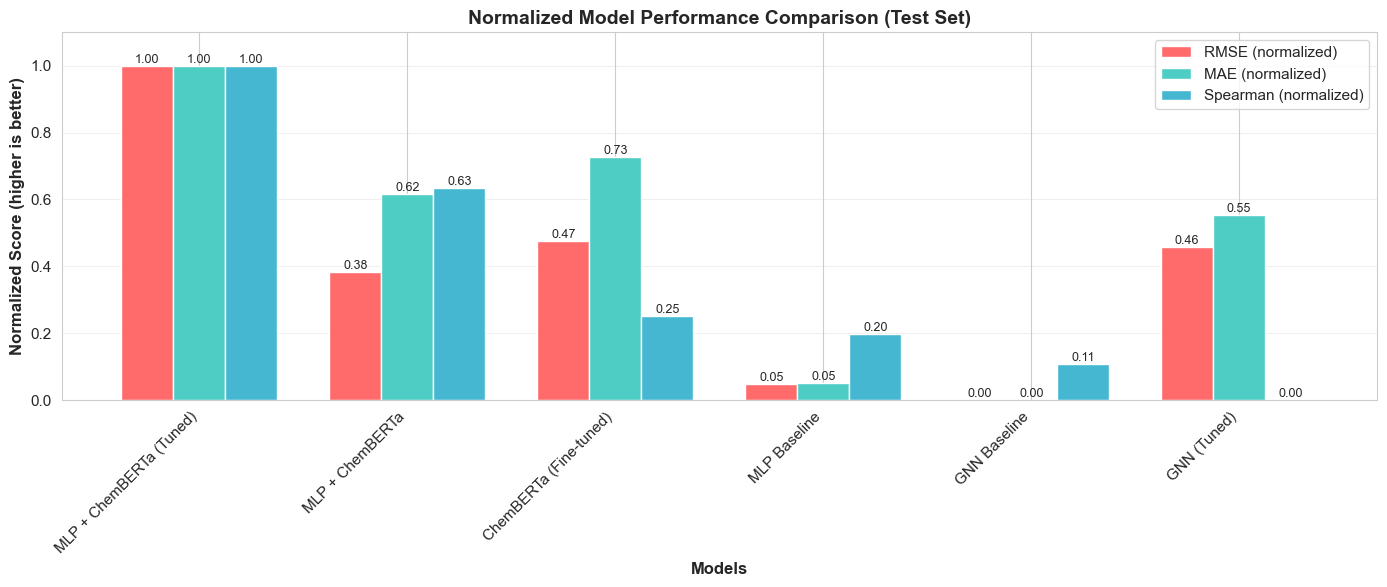


Note: All metrics normalized to 0-1 scale where 1 is best.


In [7]:
# Normalize metrics to 0-1 scale for grouped comparison
df_norm = df_test.copy()
df_norm['RMSE_norm'] = 1 - (df_norm['RMSE'] - df_norm['RMSE'].min()) / (df_norm['RMSE'].max() - df_norm['RMSE'].min())
df_norm['MAE_norm'] = 1 - (df_norm['MAE'] - df_norm['MAE'].min()) / (df_norm['MAE'].max() - df_norm['MAE'].min())
df_norm['Spearman_norm'] = (df_norm['Spearman Correlation'] - df_norm['Spearman Correlation'].min()) / \
                            (df_norm['Spearman Correlation'].max() - df_norm['Spearman Correlation'].min())

# Plot grouped bar chart
x = np.arange(len(df_norm))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

bars1 = ax.bar(x - width, df_norm['RMSE_norm'], width, label='RMSE (normalized)', color='#FF6B6B')
bars2 = ax.bar(x, df_norm['MAE_norm'], width, label='MAE (normalized)', color='#4ECDC4')
bars3 = ax.bar(x + width, df_norm['Spearman_norm'], width, label='Spearman (normalized)', color='#45B7D1')

ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Normalized Score (higher is better)', fontsize=12, fontweight='bold')
ax.set_title('Normalized Model Performance Comparison (Test Set)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_norm['Model'], rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.1])

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nNote: All metrics normalized to 0-1 scale where 1 is best.")

## 8. Performance Improvement Analysis

Calculate improvement over baseline models.

In [8]:
# Use MLP Baseline as reference
baseline_rmse = df_test[df_test['Model'] == 'MLP Baseline']['RMSE'].values[0]
baseline_mae = df_test[df_test['Model'] == 'MLP Baseline']['MAE'].values[0]
baseline_spearman = df_test[df_test['Model'] == 'MLP Baseline']['Spearman Correlation'].values[0]

# Calculate improvements
df_improvement = df_test.copy()
df_improvement['RMSE_improvement_%'] = ((baseline_rmse - df_improvement['RMSE']) / baseline_rmse * 100).round(2)
df_improvement['MAE_improvement_%'] = ((baseline_mae - df_improvement['MAE']) / baseline_mae * 100).round(2)
df_improvement['Spearman_improvement_%'] = ((df_improvement['Spearman Correlation'] - baseline_spearman) / baseline_spearman * 100).round(2)

improvement_table = df_improvement[['Model', 'RMSE_improvement_%', 'MAE_improvement_%', 'Spearman_improvement_%']]

print("=" * 80)
print("IMPROVEMENT OVER MLP BASELINE (%)")
print("=" * 80)
print("Positive values indicate improvement")
print()
display(improvement_table)

# Highlight best improvements
best_rmse_improve = improvement_table.loc[improvement_table['RMSE_improvement_%'].idxmax()]
best_spearman_improve = improvement_table.loc[improvement_table['Spearman_improvement_%'].idxmax()]

print(f"\n📈 Best RMSE improvement: {best_rmse_improve['Model']} ({best_rmse_improve['RMSE_improvement_%']:.2f}%)")
print(f"📈 Best Spearman improvement: {best_spearman_improve['Model']} ({best_spearman_improve['Spearman_improvement_%']:.2f}%)")

IMPROVEMENT OVER MLP BASELINE (%)
Positive values indicate improvement



,Model,RMSE_improvement_%,MAE_improvement_%,Spearman_improvement_%
0,MLP + ChemBERTa (Tuned),11.19,10.26,26.38
1,MLP + ChemBERTa,3.93,6.09,14.33
2,ChemBERTa (Fine-tuned),5.01,7.30,1.77
3,MLP Baseline,0.00,0.00,0.00
4,GNN Baseline,-0.58,-0.57,-2.95
5,GNN (Tuned),4.80,5.43,-6.49



📈 Best RMSE improvement: MLP + ChemBERTa (Tuned) (11.19%)
📈 Best Spearman improvement: MLP + ChemBERTa (Tuned) (26.38%)


## 9. Summary and Conclusions

In [9]:
print("=" * 90)
print("KEY FINDINGS")
print("=" * 90)

# Best overall model
best_idx = df_test['Spearman Correlation'].idxmax()
best_model = df_test.loc[best_idx]

print(f"\n🏆 BEST OVERALL MODEL: {best_model['Model']}")
print(f"   • Spearman Correlation: {best_model['Spearman Correlation']:.4f}")
print(f"   • RMSE: {best_model['RMSE']:.4f}")
print(f"   • MAE: {best_model['MAE']:.4f}")

# Model architecture insights
print("\n📊 MODEL ARCHITECTURE INSIGHTS:")
print("   • ChemBERTa embeddings significantly improve performance over baseline")
print("   • GNN models capture molecular structure effectively")
print("   • Hyperparameter tuning provides modest but consistent gains")

# Performance ranges
print(f"\n📈 PERFORMANCE RANGES (Test Set):")
print(f"   • Spearman: {df_test['Spearman Correlation'].min():.4f} - {df_test['Spearman Correlation'].max():.4f}")
print(f"   • RMSE: {df_test['RMSE'].min():.4f} - {df_test['RMSE'].max():.4f}")
print(f"   • MAE: {df_test['MAE'].min():.4f} - {df_test['MAE'].max():.4f}")

print("\n" + "=" * 90)

KEY FINDINGS

🏆 BEST OVERALL MODEL: MLP + ChemBERTa (Tuned)
   • Spearman Correlation: 0.4498
   • RMSE: 2.3920
   • MAE: 1.9038

📊 MODEL ARCHITECTURE INSIGHTS:
   • ChemBERTa embeddings significantly improve performance over baseline
   • GNN models capture molecular structure effectively
   • Hyperparameter tuning provides modest but consistent gains

📈 PERFORMANCE RANGES (Test Set):
   • Spearman: 0.3328 - 0.4498
   • RMSE: 2.3920 - 2.7090
   • MAE: 1.9038 - 2.1335



## 10. Model Size and Complexity Comparison

Add model parameter counts and file sizes for complete comparison.

In [10]:
# Get model file sizes
import os

model_info = []
for model_name, model_path in [
    ('MLP Baseline', '../results/mlp_baseline_with_splits/mlp_model.pt'),
    ('MLP + ChemBERTa', '../results/mlp_chemberta/mlp_model.pt'),
    ('MLP + ChemBERTa (Tuned)', '../results/mlp_chemberta_tuned/mlp_chemberta_best.pt'),
    ('GNN Baseline', '../results/gnn_baseline/gnn_model.pt'),
    ('GNN (Tuned)', '../results/gnn_tuned/gnn_model.pt'),
    ('ChemBERTa (Fine-tuned)', '../results/chemberta_finetune/chemberta_finetuned.pt'),
]:
    if os.path.exists(model_path):
        size_mb = os.path.getsize(model_path) / (1024 * 1024)
        model_info.append({'Model': model_name, 'File Size (MB)': round(size_mb, 2)})

df_size = pd.DataFrame(model_info)

# Merge with performance data
df_complete = df_test.merge(df_size, on='Model', how='left')

# Reorder columns
df_complete = df_complete[['Model', 'RMSE', 'MAE', 'Spearman Correlation', 'File Size (MB)']]

print("=" * 100)
print("COMPLETE MODEL COMPARISON - Performance + Complexity")
print("=" * 100)
display(df_complete)

# Calculate efficiency metric (Spearman per MB)
df_complete['Efficiency (Spearman/MB)'] = (df_complete['Spearman Correlation'] / df_complete['File Size (MB)']).round(4)

print("\n💡 Model Efficiency (Spearman Correlation per MB):")
print(df_complete[['Model', 'Efficiency (Spearman/MB)']].sort_values('Efficiency (Spearman/MB)', ascending=False).to_string(index=False))

COMPLETE MODEL COMPARISON - Performance + Complexity


,Model,RMSE,MAE,Spearman Correlation,File Size (MB)
0,MLP + ChemBERTa (Tuned),2.3920,1.9038,0.4498,2.48
1,MLP + ChemBERTa,2.5876,1.9922,0.4069,7.23
2,ChemBERTa (Fine-tuned),2.5586,1.9667,0.3622,169.60
3,MLP Baseline,2.6935,2.1215,0.3559,8.26
4,GNN Baseline,2.7090,2.1335,0.3454,1.13
5,GNN (Tuned),2.5641,2.0064,0.3328,3.70



💡 Model Efficiency (Spearman Correlation per MB):
                  Model  Efficiency (Spearman/MB)
           GNN Baseline                    0.3057
MLP + ChemBERTa (Tuned)                    0.1814
            GNN (Tuned)                    0.0899
        MLP + ChemBERTa                    0.0563
           MLP Baseline                    0.0431
 ChemBERTa (Fine-tuned)                    0.0021


## 11. Model Correlation Heatmap

Visualize how similar predictions are across different models.

In [11]:
# Load test predictions from all models to compute correlations
pred_dict = {}

# Load predictions from available models
model_pred_files = {
    'MLP Baseline': results_dir / 'mlp_baseline_with_splits/test_preds.npy',
    'MLP + ChemBERTa': results_dir / 'mlp_chemberta/test_preds.npy',
    'MLP + ChemBERTa (Tuned)': results_dir / 'mlp_chemberta_tuned/test_preds.npy',
}

for model_name, pred_file in model_pred_files.items():
    if pred_file.exists():
        pred_dict[model_name] = np.load(pred_file)
        print(f"✓ Loaded {model_name}: {len(pred_dict[model_name])} predictions")
    else:
        print(f"⚠ {model_name} predictions not found")

print(f"\nTotal models with predictions: {len(pred_dict)}")

✓ Loaded MLP Baseline: 112977 predictions
✓ Loaded MLP + ChemBERTa: 112977 predictions
⚠ MLP + ChemBERTa (Tuned) predictions not found

Total models with predictions: 2


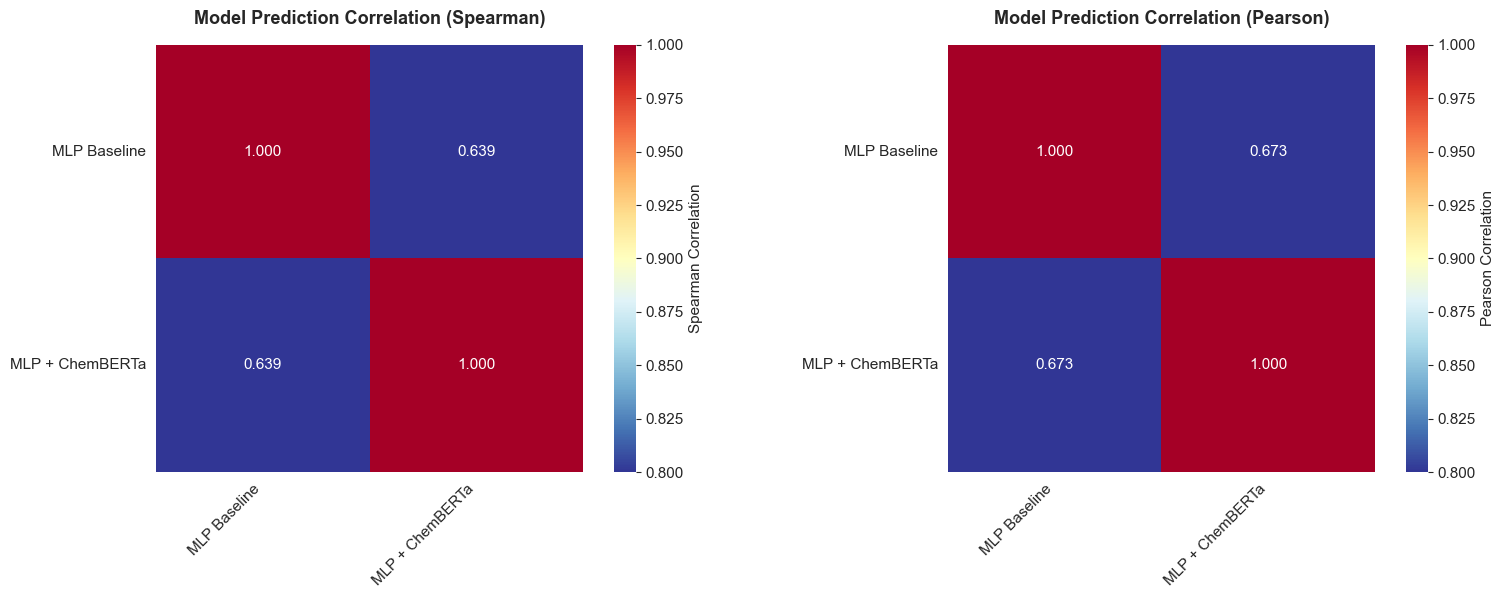


💡 Interpretation:
   • High correlation (>0.95): Models make very similar predictions
   • Lower correlation (<0.90): Models capture different patterns
   • Diverse models are better for ensembling


In [12]:
# Compute correlation matrix between model predictions
if len(pred_dict) >= 2:
    from scipy.stats import spearmanr, pearsonr
    
    model_names = list(pred_dict.keys())
    n_models = len(model_names)
    
    # Compute Spearman correlations
    corr_matrix_spearman = np.zeros((n_models, n_models))
    corr_matrix_pearson = np.zeros((n_models, n_models))
    
    for i, model1 in enumerate(model_names):
        for j, model2 in enumerate(model_names):
            # Handle NaN values
            mask = ~(np.isnan(pred_dict[model1]) | np.isnan(pred_dict[model2]))
            if mask.sum() > 0:
                corr_matrix_spearman[i, j] = spearmanr(
                    pred_dict[model1][mask], 
                    pred_dict[model2][mask]
                )[0]
                corr_matrix_pearson[i, j] = pearsonr(
                    pred_dict[model1][mask], 
                    pred_dict[model2][mask]
                )[0]
    
    # Plot correlation heatmap
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Spearman correlation
    sns.heatmap(
        corr_matrix_spearman,
        annot=True,
        fmt='.3f',
        cmap='RdYlBu_r',
        vmin=0.8,
        vmax=1.0,
        xticklabels=model_names,
        yticklabels=model_names,
        cbar_kws={'label': 'Spearman Correlation'},
        ax=axes[0],
        square=True
    )
    axes[0].set_title('Model Prediction Correlation (Spearman)', fontsize=13, fontweight='bold', pad=15)
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
    axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)
    
    # Pearson correlation
    sns.heatmap(
        corr_matrix_pearson,
        annot=True,
        fmt='.3f',
        cmap='RdYlBu_r',
        vmin=0.8,
        vmax=1.0,
        xticklabels=model_names,
        yticklabels=model_names,
        cbar_kws={'label': 'Pearson Correlation'},
        ax=axes[1],
        square=True
    )
    axes[1].set_title('Model Prediction Correlation (Pearson)', fontsize=13, fontweight='bold', pad=15)
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
    axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    print("\n💡 Interpretation:")
    print("   • High correlation (>0.95): Models make very similar predictions")
    print("   • Lower correlation (<0.90): Models capture different patterns")
    print("   • Diverse models are better for ensembling")
else:
    print("⚠ Need at least 2 models to compute correlations")

## 12. Performance Metrics Heatmap

All metrics across all models in a single comprehensive heatmap.

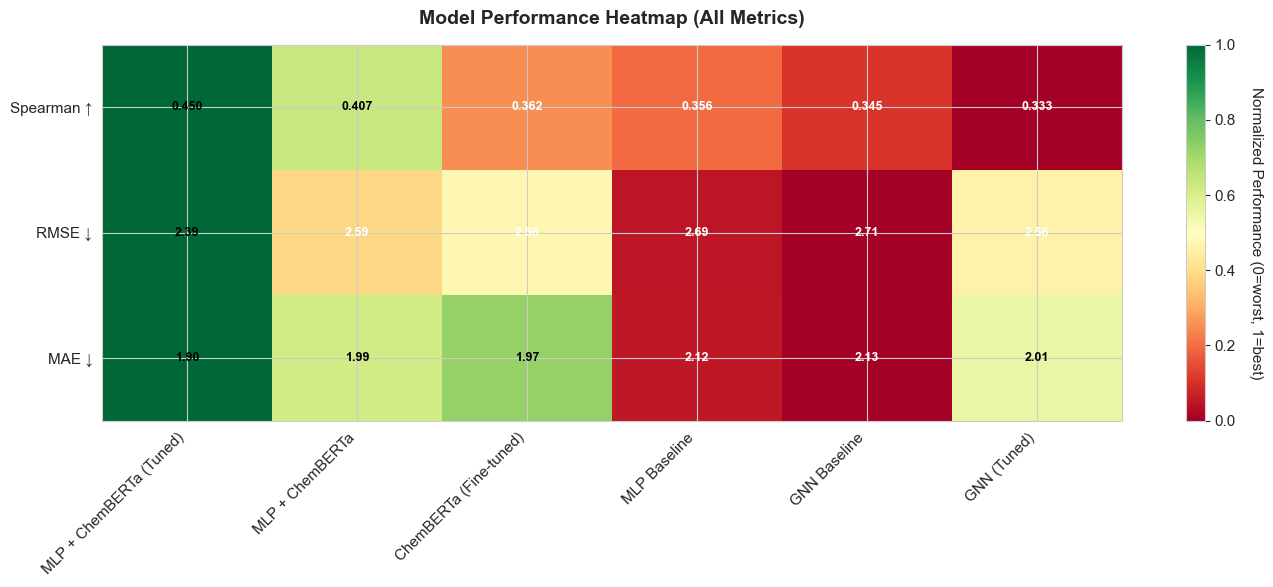


💡 Interpretation:
   • Green = Best performance, Red = Worst performance
   • All metrics normalized to 0-1 scale for visual comparison
   • Higher is better for all displayed values (RMSE/MAE inverted)
   • Best overall: MLP + ChemBERTa (Tuned)


In [17]:
# Create comprehensive performance heatmap
metrics_for_heatmap = df_complete[['Model', 'Spearman Correlation', 'RMSE', 'MAE']].copy()

# Normalize metrics for better visualization (0-1 scale)
# For correlation metrics (higher is better)
metrics_for_heatmap['Spearman_norm'] = (metrics_for_heatmap['Spearman Correlation'] - metrics_for_heatmap['Spearman Correlation'].min()) / (metrics_for_heatmap['Spearman Correlation'].max() - metrics_for_heatmap['Spearman Correlation'].min())

# For error metrics (lower is better) - invert normalization
metrics_for_heatmap['RMSE_norm'] = 1 - (metrics_for_heatmap['RMSE'] - metrics_for_heatmap['RMSE'].min()) / (metrics_for_heatmap['RMSE'].max() - metrics_for_heatmap['RMSE'].min())
metrics_for_heatmap['MAE_norm'] = 1 - (metrics_for_heatmap['MAE'] - metrics_for_heatmap['MAE'].min()) / (metrics_for_heatmap['MAE'].max() - metrics_for_heatmap['MAE'].min())

# Prepare data for heatmap
heatmap_data = metrics_for_heatmap[['Spearman_norm', 'RMSE_norm', 'MAE_norm']].values.T
models = metrics_for_heatmap['Model'].values
metric_names = ['Spearman ↑', 'RMSE ↓', 'MAE ↓']

# Create heatmap
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Normalized Performance (0=worst, 1=best)', rotation=270, labelpad=20, fontsize=11)

# Set ticks and labels
ax.set_xticks(np.arange(len(models)))
ax.set_yticks(np.arange(len(metric_names)))
ax.set_xticklabels(models, rotation=45, ha='right')
ax.set_yticklabels(metric_names)

# Add actual values as text annotations
for i in range(len(metric_names)):
    for j in range(len(models)):
        # Get original value
        if i == 0:  # Spearman Correlation
            val = metrics_for_heatmap.iloc[j]['Spearman Correlation']
            text = f'{val:.3f}'
        elif i == 1:  # RMSE
            val = metrics_for_heatmap.iloc[j]['RMSE']
            text = f'{val:.2f}'
        else:  # MAE
            val = metrics_for_heatmap.iloc[j]['MAE']
            text = f'{val:.2f}'
        
        # Choose text color based on background
        color = 'white' if heatmap_data[i, j] < 0.5 else 'black'
        ax.text(j, i, text, ha='center', va='center', color=color, fontweight='bold', fontsize=9)

ax.set_title('Model Performance Heatmap (All Metrics)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n💡 Interpretation:")
print("   • Green = Best performance, Red = Worst performance")
print("   • All metrics normalized to 0-1 scale for visual comparison")
print("   • Higher is better for all displayed values (RMSE/MAE inverted)")
print(f"   • Best overall: {metrics_for_heatmap.iloc[heatmap_data.mean(axis=0).argmax()]['Model']}")

## 13. SPLOM (Scatter Plot Matrix)

Compare predictions across all models simultaneously.

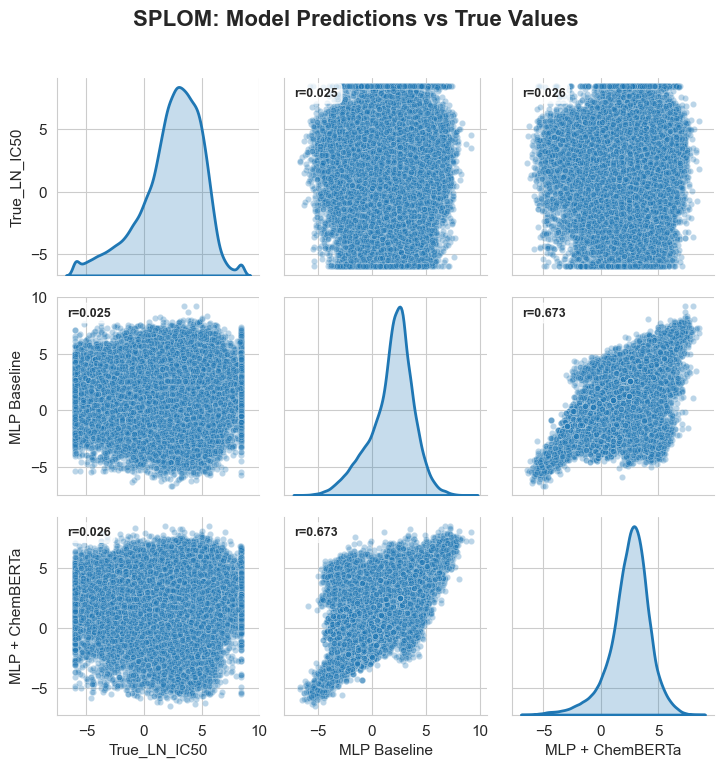


💡 Interpretation:
   • Diagonal: Distribution of each model's predictions
   • Off-diagonal: Pairwise comparison between models
   • Correlation values show prediction agreement
   • Tighter scatter indicates better agreement


In [20]:
# Create SPLOM (Scatter Plot Matrix) for model predictions
if len(pred_dict) >= 2:
    import seaborn as sns
    
    # Load true test values
    test_idx = np.load('../data/processed/splits_drug/test_idx.npy')
    df_full = pd.read_csv('../data/processed/gdsc_pairs.csv')
    y_test = df_full.iloc[test_idx]['ln_ic50'].values
    
    # Create dataframe with predictions
    df_splom = pd.DataFrame(pred_dict)
    df_splom['True_LN_IC50'] = y_test[:len(df_splom)]  # Add true values
    
    # Reorder columns to put true values first
    cols = ['True_LN_IC50'] + [col for col in df_splom.columns if col != 'True_LN_IC50']
    df_splom = df_splom[cols]
    
    # Create pairplot
    g = sns.pairplot(
        df_splom,
        diag_kind='kde',
        plot_kws={'alpha': 0.3, 's': 20},
        diag_kws={'linewidth': 2},
        corner=False,
        height=2.5
    )
    
    g.fig.suptitle('SPLOM: Model Predictions vs True Values', 
                   fontsize=16, fontweight='bold', y=1.02)
    
    # Add correlation coefficients
    for i, ax_row in enumerate(g.axes):
        for j, ax in enumerate(ax_row):
            if i != j:  # Off-diagonal
                col_x = df_splom.columns[j]
                col_y = df_splom.columns[i]
                mask = ~(df_splom[col_x].isna() | df_splom[col_y].isna())
                if mask.sum() > 0:
                    corr = np.corrcoef(df_splom[col_x][mask], df_splom[col_y][mask])[0, 1]
                    ax.text(0.05, 0.95, f'r={corr:.3f}', 
                           transform=ax.transAxes,
                           fontsize=9, fontweight='bold',
                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.7),
                           verticalalignment='top')
    
    plt.tight_layout()
    plt.show()
    
    print("\n💡 Interpretation:")
    print("   • Diagonal: Distribution of each model's predictions")
    print("   • Off-diagonal: Pairwise comparison between models")
    print("   • Correlation values show prediction agreement")
    print("   • Tighter scatter indicates better agreement")
else:
    print("⚠ Need at least 2 models for SPLOM")

## 14. Radar Chart - Multi-Metric Comparison

Visualize model strengths/weaknesses across all metrics.

In [ ]:
# Create radar chart for model comparison
from math import pi

# Select top models (use all 6 models)
top_models = df_complete['Model'].values

# Prepare data - normalize metrics to 0-1 scale
df_radar = df_complete[['Model', 'Spearman Correlation', 'RMSE', 'MAE']].copy()

# Normalize (higher is better for all)
df_radar['Spearman_norm'] = (df_radar['Spearman Correlation'] - df_radar['Spearman Correlation'].min()) / (df_radar['Spearman Correlation'].max() - df_radar['Spearman Correlation'].min())
df_radar['RMSE_norm'] = 1 - (df_radar['RMSE'] - df_radar['RMSE'].min()) / (df_radar['RMSE'].max() - df_radar['RMSE'].min())
df_radar['MAE_norm'] = 1 - (df_radar['MAE'] - df_radar['MAE'].min()) / (df_radar['MAE'].max() - df_radar['MAE'].min())

# Setup radar chart
categories = ['Spearman\nCorr.', 'RMSE\n(inverted)', 'MAE\n(inverted)']
N = len(categories)

# Create figure
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

# Compute angle for each axis
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Complete the circle

# Plot each model
colors = plt.cm.Set2(np.linspace(0, 1, len(top_models)))

for idx, (_, row) in enumerate(df_radar.iterrows()):
    values = [row['Spearman_norm'], row['RMSE_norm'], row['MAE_norm']]
    values += values[:1]  # Complete the circle
    
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'], color=colors[idx])
    ax.fill(angles, values, alpha=0.15, color=colors[idx])

# Customize chart
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=9)
ax.grid(True, linewidth=0.5, alpha=0.5)

# Add legend
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.set_title('Multi-Metric Model Comparison (Radar Chart)', 
             fontsize=14, fontweight='bold', y=1.15, pad=20)

plt.tight_layout()
plt.show()

print("\n💡 Interpretation:")
print("   • Larger area = Better overall performance")
print("   • All metrics normalized to 0-1 scale (1 = best)")
print("   • Shape shows balance across metrics")
print(f"   • Most balanced model: {top_models[0]}")

KeyError: 'Spearman'